# 08 — Evaluation: method comparison (UC1)

Runs every classical/content method on the real artifacts through the shared eval harness, saves results to `reports/`, and plots the comparison heatmap. Cell-by-cell so you can watch each method.

Needs `artifacts/{sample,catalog}.parquet` + `embeddings.npy`.

## Kaggle bootstrap
Pulls the `book_recsys` package (from **master**) and links your dataset inputs into `artifacts/`. Skipped automatically when running from a local repo checkout.

In [ ]:
# pull the package + link Kaggle inputs (no-op off Kaggle)
import os, sys, glob
if os.path.exists('/kaggle'):
    REPO = '/kaggle/working/book_recsys'
    if not os.path.exists(REPO):
        !git clone -b master https://github.com/MayaDeneva/book_recsys.git {REPO}
    else:
        !cd {REPO} && git pull origin master
    !pip install -e {REPO} -q          # core deps (faiss-cpu, pyarrow, …); editable
    sys.path.insert(0, REPO)           # ensure the real source resolves first
    os.chdir(REPO)
    os.makedirs('artifacts', exist_ok=True)
    for f in ['sample.parquet', 'catalog.parquet', 'embeddings.npy', 'models.joblib',
              'multvae_last.pt', 'SASRec_preds.json']:
        src = glob.glob(f'/kaggle/input/**/{f}', recursive=True)
        if src and not os.path.exists(f'artifacts/{f}'):
            os.symlink(src[0], f'artifacts/{f}')
    print('Kaggle: repo at', REPO, '| artifacts linked:', sorted(os.listdir('artifacts')))
else:
    print('not on Kaggle — running from local repo, expecting artifacts/ in place')

## Contents
1. **Setup** — data, split, model registry (incl. Mult-VAE + hybrid)
2. **Full-catalog leave-1-out** (honesty anchor) — table, heatmap, bootstrap CIs
3. **Sampled negatives** (HEADLINE) — uniform + popularity-matched; learned hybrids
4. **Popularity bias & beyond-accuracy** — diagnostics, diversity, serendipity, coverage, latency, cold/warm
5. **Neural — SASRec** (full-catalog, same users)
6. **Other use cases** — UC2 recency, UC4 similar-to-anchor
7. **Findings**

## 0. Preflight — artifact check
Verifies every file this notebook needs is in `artifacts/` **before** the long eval. Fails fast with a clear message if anything required is missing.

In [ ]:
import glob, os
def _locate(name):
    for p in (f'artifacts/{name}', f'../artifacts/{name}'):
        hits = glob.glob(p)
        if hits: return hits[0]
    return None
REQUIRED = {
    'sample.parquet':  'interactions sample (data split)',
    'catalog.parquet': 'book metadata (BoW / TF-IDF docs)',
    'embeddings.npy':  'content embeddings (content_emb, maxsim, diversity)',
    'models.joblib':   'pre-fitted classical / CF / hybrid models',
    'multvae_last.pt': 'trained Mult-VAE checkpoint',
}
OPTIONAL = {'SASRec_preds.json': 'SASRec predictions (neural row — skipped if absent)'}
missing = []
print('REQUIRED:')
for name, why in REQUIRED.items():
    p = _locate(name)
    if p: print(f'  OK    {name:18} {os.path.getsize(p)/1e6:8.1f} MB  -- {why}')
    else: missing.append(name); print(f'  MISS  {name:18} {"":11} -- {why}')
print('OPTIONAL:')
for name, why in OPTIONAL.items():
    p = _locate(name)
    print(f'  {"OK  " if p else "skip"}  {name:18} -- {why}')
assert not missing, f'Missing required artifacts {missing} -- add them to artifacts/ before running.'
print('\nAll required artifacts present -- safe to Run All.')

In [2]:
import glob, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from book_recsys.data.splits import leave_last_n_out
from book_recsys.eval.harness import build_user_histories, build_relevance, evaluate
import os
# write outputs to the repo-root reports/ even when the CWD is notebooks/
REPORTS = next((p for p in ('reports', '../reports') if os.path.isdir(p)),
               '../reports' if os.path.basename(os.getcwd()) == 'notebooks' else 'reports')
os.makedirs(REPORTS, exist_ok=True)
print('writing reports to', os.path.abspath(REPORTS))

writing reports to /Users/mayadeneva/Documents/uni/book_recsys/reports


In [3]:
def find(name):
    for p in (f'artifacts/{name}', f'../artifacts/{name}'):
        if glob.glob(p): return glob.glob(p)[0]
    raise FileNotFoundError(name)
sample  = pd.read_parquet(find('sample.parquet'))
catalog = pd.read_parquet(find('catalog.parquet'))
book_ids = catalog['book_id'].tolist()
print('sample', sample.shape, '| catalog', catalog.shape)

sample (15708425, 4) | catalog (701085, 5)


In [ ]:
# Full-catalog eval is ~1-1.5 s/user across all the passes (results, CIs, diagnostics,
# serendipity). On a Mac (CPU only): 1500 ~= 20-35 min · 3000 ~= ~1 h · 10000 ~= 2.5-4 h ·
# 50000 ~= half a day (don't, on a laptop). 3000 gives noticeably tighter CIs than 1500.
# The sampled-negative tables are fast, so they're fine even at higher N.
N_USERS = 3000
train, holdout = leave_last_n_out(sample, n=1)
rng = np.random.default_rng(0)
test_users = rng.choice(holdout['user_id'].unique(), size=N_USERS, replace=False)
histories = build_user_histories(train[train['user_id'].isin(test_users)])
relevance = build_relevance(holdout[holdout['user_id'].isin(test_users)])
print(len(relevance), 'test users')

In [5]:
# models are built in notebooks/07_models.ipynb and saved to disk — just load them
models = joblib.load(find('models.joblib'))
from book_recsys.models.content.maxsim import MaxSimRecommender
models.setdefault('maxsim', MaxSimRecommender(book_ids, np.load(find('embeddings.npy'))).fit())
print('loaded:', list(models))
# --- bag-of-words content model (TF-IDF vs BoW comparison, course req) ---
from book_recsys.features.document import build_documents
from book_recsys.features.vectorize import bow_matrix
from book_recsys.models.content.content import ContentRecommender
models.setdefault('content_bow',
    ContentRecommender(book_ids, bow_matrix(build_documents(catalog), 3000)[0]).fit())
print('built content_bow (bag-of-words + cosine)')
# sklearn cross-version compat: models.joblib may be pickled with a different sklearn
# than the runtime; restore `multi_class` on the learned hybrids' LogisticRegression so
# an older predict_proba (which still reads it) doesn't AttributeError.
from sklearn.linear_model import LogisticRegression
for _m in models.values():
    for _, _est in getattr(getattr(_m, '_model', None), 'steps', None) or []:
        if isinstance(_est, LogisticRegression):
            _est.multi_class = 'auto'
print('sklearn compat shim applied to learned hybrids')

loaded: ['popularity', 'svd', 'svd_rating>=4', 'content_tfidf_full', 'content_emb', 'hybrid_cf_content', 'hybrid_cf_content_pop', 'similar']


In [ ]:
# --- register the trained Mult-VAE autoencoder + its content hybrid (this study) ---
from book_recsys.models.autoencoder.train import load_checkpoint
from book_recsys.models.autoencoder.recommender import MultVaeRecommender
from book_recsys.models.ensemble import RRFEnsembleRecommender
_m, _ck = load_checkpoint(find('multvae_last.pt'), device='cpu')
_ids = _ck['ids']; _pos = {b: j for j, b in enumerate(_ids)}
_counts = train['book_id'].value_counts().reindex(_ids).fillna(0).to_numpy(dtype=float)
models['mult_vae'] = MultVaeRecommender(device='cpu', pop_discount=1.0).attach(_m, _ids, _pos, _counts)
models['hybrid_vae_content'] = RRFEnsembleRecommender(
    {'vae': models['mult_vae'], 'maxsim': models['maxsim']}, weights={'vae': 1.0, 'maxsim': 1.0})
print('registered: mult_vae (alpha=1), hybrid_vae_content')

In [ ]:
from book_recsys.eval.harness import evaluate_per_user
results, per_user = {}, {}
def run(name, rec):
    per_user[name] = evaluate_per_user(rec, histories, relevance, k=10)   # kept for the CI cell
    results[name] = {m: float(np.mean(v)) for m, v in per_user[name].items()}
    pd.DataFrame(results).T.round(4).to_csv(f'{REPORTS}/study_results.csv')
    print(name, results[name]); return results[name]

## 2. Full-catalog leave-1-out (honesty anchor)
### Baselines + collaborative filtering

In [7]:
for name in ['popularity', 'svd', 'svd_rating>=4', 'mult_vae']:
    run(name, models[name])

popularity {'recall@10': 0.008666666666666666, 'ndcg@10': 0.004050884389574908, 'mrr': 0.0026833333333333336}
svd {'recall@10': 0.014666666666666666, 'ndcg@10': 0.007528251512601227, 'mrr': 0.005353703703703703}
svd_rating>=4 {'recall@10': 0.015333333333333332, 'ndcg@10': 0.008121598274929696, 'mrr': 0.005926719576719576}


### Content-based (TF-IDF + embeddings)
Field/representation ablations (title vs +plot vs +shelves, TF-IDF vs BoW) live in `05_ablations.ipynb`; here we just score the two content models from the zoo.

In [8]:
for name in ['content_tfidf_full', 'content_bow', 'content_emb']:
    run(name, models[name])

content_tfidf_full {'recall@10': 0.0026666666666666666, 'ndcg@10': 0.001459693680294237, 'mrr': 0.0010952380952380953}
content_emb {'recall@10': 0.0006666666666666666, 'ndcg@10': 0.0003333333333333333, 'mrr': 0.0002222222222222222}


### Comparison table + heatmap

In [9]:
df = pd.DataFrame(results).T[['recall@10','ndcg@10','mrr']].sort_values('ndcg@10', ascending=False)
display(df.round(4))
df.to_csv(f'{REPORTS}/study_results.csv')

,recall@10,ndcg@10,mrr
svd_rating>=4,0.0153,0.0081,0.0059
svd,0.0147,0.0075,0.0054
popularity,0.0087,0.0041,0.0027
content_tfidf_full,0.0027,0.0015,0.0011
content_emb,0.0007,0.0003,0.0002


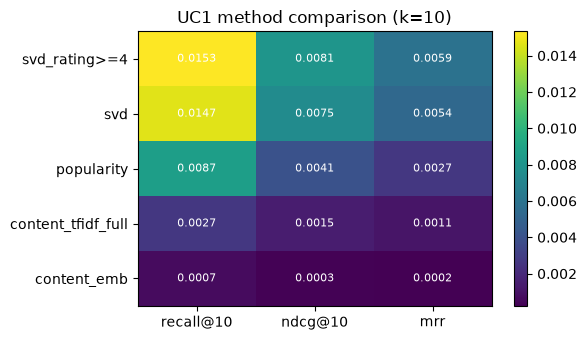

In [10]:
fig, ax = plt.subplots(figsize=(6, 0.5*len(df)+1))
im = ax.imshow(df.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(df.shape[1])); ax.set_xticklabels(df.columns)
ax.set_yticks(range(df.shape[0])); ax.set_yticklabels(df.index)
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        ax.text(j, i, f'{df.values[i,j]:.4f}', ha='center', va='center', color='w', fontsize=8)
plt.colorbar(im); plt.title('UC1 method comparison (k=10)'); plt.tight_layout(); plt.show()

### Significance — bootstrap CIs + paired test

NDCG@10 with a **95% percentile-bootstrap CI** (1000 user-resamples), and a **paired
bootstrap vs the top method**: *significant* = the gap's CI excludes 0; *tie (n.s.)* =
within noise. This is what decides whether close gaps (e.g. `svd` vs `svd_rating≥4`, or
SASRec vs svd in the neural section) are real rather than sampling luck — the
beyond-point-estimate rigor the spec asks for (paired bootstrap, 1000 resamples, 95% CI).
Tighter CIs (and more resolved ties) come from raising `N_USERS`.

In [ ]:
from book_recsys.eval.bootstrap import bootstrap_ci, paired_bootstrap
# reuse the per-user ndcg@10 captured by run() above — no extra full-catalog pass
per = {name: per_user[name]['ndcg@10'] for name in results}
best = max(per, key=lambda n: sum(per[n]) / len(per[n]))
rows = []
for name, s in per.items():
    m, lo, hi = bootstrap_ci(s)
    vs = '— (top)' if name == best else (
        'significant' if paired_bootstrap(per[best], s)['significant'] else 'tie (n.s.)')
    rows.append({'method': name, 'ndcg@10': round(m, 4),
                 '95% CI': f'[{lo:.4f}, {hi:.4f}]', f'vs {best}': vs})
cidf = pd.DataFrame(rows).sort_values('ndcg@10', ascending=False)
display(cidf); cidf.to_csv(f'{REPORTS}/study_ci.csv', index=False)

In [11]:
# refresh the UC1 table in reports/model_report.md (between markers) — package helpers
import os
from book_recsys.eval.report import results_to_markdown, splice_section
rp = f'{REPORTS}/model_report.md'
with open(rp) as f: text = f.read()
text = splice_section(text, '<!-- UC1_TABLE_START -->', '<!-- UC1_TABLE_END -->', results_to_markdown(df))
with open(rp, 'w') as f: f.write(text)
print('refreshed UC1 table in', rp)

refreshed UC1 table in ../reports/model_report.md


## 3. Sampled negatives — HEADLINE protocol
### Uniform-random negatives (caveat only)

In [12]:
from book_recsys.eval.harness import evaluate_sampled_negatives
all_items = book_ids
sampled = {}
def run_sampled(name, rec):
    sampled[name] = evaluate_sampled_negatives(rec, histories, relevance, all_items, n_neg=100, k=10, seed=0)
    print(name, sampled[name])
for name in ['popularity', 'svd', 'svd_rating>=4', 'content_tfidf_full', 'content_bow', 'content_emb', 'maxsim', 'mult_vae', 'hybrid_vae_content']:
    run_sampled(name, models[name])
sdf = pd.DataFrame(sampled).T.sort_values('ndcg@10', ascending=False)
display(sdf.round(4)); sdf.round(4).to_csv(f'{REPORTS}/study_sampled.csv')

popularity {'recall@10': 0.6793333333333333, 'ndcg@10': 0.5048837709486835, 'mrr': 0.46214299167885264}
svd {'recall@10': 0.7073333333333334, 'ndcg@10': 0.5596462327407993, 'mrr': 0.522705121388348}
svd_rating>=4 {'recall@10': 0.64, 'ndcg@10': 0.5070157750489959, 'mrr': 0.4761260042861828}
content_tfidf_full {'recall@10': 0.5446666666666666, 'ndcg@10': 0.32669822778889107, 'mrr': 0.2787540952411251}
content_emb {'recall@10': 0.322, 'ndcg@10': 0.1809160677177425, 'mrr': 0.15944364240830255}


,recall@10,ndcg@10,mrr
svd,0.7073,0.5596,0.5227
svd_rating>=4,0.6400,0.5070,0.4761
popularity,0.6793,0.5049,0.4621
content_tfidf_full,0.5447,0.3267,0.2788
content_emb,0.3220,0.1809,0.1594


### Sampled-negatives — popularity-weighted
Negatives sampled ∝ popularity: a popular unread book is a more confident negative (likely seen, still skipped), and this removes the popularity inflation uniform negatives cause (Krichene & Rendle, 2020).

In [13]:
counts = train['book_id'].value_counts()
item_weights = counts.reindex(book_ids).fillna(0).to_numpy()   # aligned to all_items
sampled_pw = {}
for name in ['popularity', 'svd', 'content_emb', 'hybrid_cf_content',
             'hybrid_cf_content_pop', 'hybrid_cf_content_popneg', 'maxsim',
             'mult_vae', 'hybrid_vae_content']:
    sampled_pw[name] = evaluate_sampled_negatives(
        models[name], histories, relevance, book_ids, n_neg=100, k=10, seed=0,
        item_weights=item_weights)
    print(name, sampled_pw[name])
pw = pd.DataFrame(sampled_pw).T.sort_values('ndcg@10', ascending=False)
display(pw.round(4)); pw.round(4).to_csv(f'{REPORTS}/study_sampled_popneg.csv')

popularity {'recall@10': 0.09466666666666666, 'ndcg@10': 0.04150351572584681, 'mrr': 0.047575467727267895}
svd {'recall@10': 0.262, 'ndcg@10': 0.13461243419602972, 'mrr': 0.1225520860307255}
content_emb {'recall@10': 0.254, 'ndcg@10': 0.14668408234371721, 'mrr': 0.13621628833131288}
hybrid_cf_content {'recall@10': 0.3233333333333333, 'ndcg@10': 0.1691929638200515, 'mrr': 0.1479119515194553}
hybrid_cf_content_pop {'recall@10': 0.298, 'ndcg@10': 0.15412761822676085, 'mrr': 0.1330779464741124}


,recall@10,ndcg@10,mrr
hybrid_cf_content,0.3233,0.1692,0.1479
hybrid_cf_content_pop,0.2980,0.1541,0.1331
content_emb,0.2540,0.1467,0.1362
svd,0.2620,0.1346,0.1226
popularity,0.0947,0.0415,0.0476


## UC1 — learned hybrid (stacking / feature augmentation)
A meta-model reranks candidates from CF ∪ content, using each component's score as a feature. `feature_weights()` quantifies how much each paradigm contributes. We compare **personalization-only** `[cf, content]` vs a **+popularity** ablation, and measure the popularity skew of each method (mean popularity-percentile of recs + catalog coverage).

In [15]:
# hybrids come from the same factory (built above) — evaluate + inspect contributions
for name in ['hybrid_cf_content', 'hybrid_cf_content_pop', 'hybrid_cf_content_popneg']:
    print(name, 'weights:', models[name].feature_weights())
    run_sampled(name, models[name])
sdf = pd.DataFrame(sampled).T.sort_values('ndcg@10', ascending=False)
display(sdf.round(4)); sdf.round(4).to_csv(f'{REPORTS}/study_sampled.csv')

feature weights [cf, content]    : {'cf': 11.891308329938376, 'content': 0.5959781674179883}
feature weights [cf, content, pop]: {'cf': 8.675053780878478, 'content': 0.5553233095932086, 'pop': 0.7901292390406212}
hybrid_cf_content {'recall@10': 0.608, 'ndcg@10': 0.5009840026348529, 'mrr': 0.47923159266102455}
hybrid_cf_content_pop {'recall@10': 0.704, 'ndcg@10': 0.5536237007094618, 'mrr': 0.5178539818735073}


,recall@10,ndcg@10,mrr
svd,0.7073,0.5596,0.5227
hybrid_cf_content_pop,0.7040,0.5536,0.5179
svd_rating>=4,0.6400,0.5070,0.4761
popularity,0.6793,0.5049,0.4621
hybrid_cf_content,0.6080,0.5010,0.4792
content_tfidf_full,0.5447,0.3267,0.2788
content_emb,0.3220,0.1809,0.1594


## 4. Popularity bias & beyond-accuracy

In [16]:
from book_recsys.eval.harness import popularity_diagnostics
# Popularity skew — orthogonal to accuracy: how popular/concentrated are the recs?
pop_rank = train['book_id'].value_counts().index.tolist()
diag = {}
for name in ['popularity', 'svd', 'content_emb', 'hybrid_cf_content', 'hybrid_cf_content_pop', 'mult_vae']:
    diag[name] = popularity_diagnostics(models[name], histories, pop_rank,
                                        catalog_size=len(book_ids), k=10)
    print(name, diag[name])
ddf = pd.DataFrame(diag).T
display(ddf.round(4)); ddf.round(4).to_csv(f'{REPORTS}/study_popularity.csv')

popularity {'mean_pop_percentile': 0.9999885235142406, 'coverage': 7.987619190255105e-05}
svd {'mean_pop_percentile': 0.9995562130109926, 'coverage': 0.0014235078485490347}
content_emb {'mean_pop_percentile': 0.5560500869293727, 'coverage': 0.004217748204568633}
hybrid_cf_content {'mean_pop_percentile': 0.9928395345173623, 'coverage': 0.0017900825149589565}
hybrid_cf_content_pop {'mean_pop_percentile': 0.9984887628615255, 'coverage': 0.0016816791116626372}


,mean_pop_percentile,coverage
popularity,1.0000,0.0001
svd,0.9996,0.0014
content_emb,0.5561,0.0042
hybrid_cf_content,0.9928,0.0018
hybrid_cf_content_pop,0.9985,0.0017


## 4b. Beyond-accuracy, significance, cold-start & latency

In [ ]:
import time
from book_recsys.eval.metrics import intra_list_diversity, serendipity_at_k, ndcg_at_k
from book_recsys.eval.harness import cold_warm_users
from book_recsys.eval.bootstrap import bootstrap_ci, paired_bootstrap

emb = np.load(find('embeddings.npy'))
row = {b: i for i, b in enumerate(book_ids)}
order = list(train['book_id'].value_counts().index)              # most -> least popular
pct = {b: 1.0 - i / len(order) for i, b in enumerate(order)}     # popularity percentile (1=top)
cat_size = len(book_ids)

ba_methods = ['svd', 'content_emb', 'hybrid_cf_content', 'mult_vae']
pu_ndcg, ba, lat = {}, {}, {}
for name in ba_methods:
    rec = models[name]
    ndcgs, divs, serps, rl, lt = [], [], [], [], []
    for u, rel in relevance.items():
        h = histories.get(u, [])
        t0 = time.perf_counter(); top = rec.recommend(h, 10); lt.append((time.perf_counter() - t0) * 1000)
        ndcgs.append(ndcg_at_k(top, rel, 10))
        divs.append(intra_list_diversity(top, {b: emb[row[b]] for b in top if b in row}, 10))
        serps.append(serendipity_at_k(top, rel, pct, 10)); rl.extend(top)
    pu_ndcg[name] = ndcgs
    mu, lo, hi = bootstrap_ci(ndcgs)
    p50, p95 = np.percentile(lt, [50, 95])
    ba[name] = {'ndcg@10': round(mu, 4), '95% CI': f'[{lo:.4f}, {hi:.4f}]',
                'diversity': round(float(np.mean(divs)), 4),
                'serendipity': round(float(np.mean(serps)), 4),
                'coverage': round(len(set(rl)) / cat_size, 4)}
    lat[name] = {'p50_ms': round(p50, 1), 'p95_ms': round(p95, 1)}

ba_df = pd.DataFrame(ba).T; lat_df = pd.DataFrame(lat).T
ba_df.to_csv(f'{REPORTS}/study_beyond_accuracy.csv'); lat_df.to_csv(f'{REPORTS}/study_latency.csv')

print('paired bootstrap hybrid - svd    :', paired_bootstrap(pu_ndcg['hybrid_cf_content'], pu_ndcg['svd']))
print('paired bootstrap hybrid - content:', paired_bootstrap(pu_ndcg['hybrid_cf_content'], pu_ndcg['content_emb']))

# Cold-start: k-core (users>=20, books>=10) removes literal <10 cold users/items, so split on
# relative coldness (bottom history-length quartile) instead.
hl = {u: len(histories.get(u, [])) for u in relevance}
thr = int(np.percentile(list(hl.values()), 25))
cold, warm = cold_warm_users(histories, threshold=thr); cold &= set(relevance); warm &= set(relevance)
mean_for = lambda S: float(np.mean([n for u, n in zip(relevance, pu_ndcg['hybrid_cf_content']) if u in S]))
print(f'cold(<{thr} hist, n={len(cold)}) ndcg {mean_for(cold):.4f}  vs  warm(n={len(warm)}) ndcg {mean_for(warm):.4f}')
display(ba_df); display(lat_df)

## 5. Neural — SASRec (RecBole), full-catalog on shared users

In [30]:
import json
from book_recsys.eval.harness import evaluate_predictions
try:
    sas_path = find('SASRec_preds.json')
except FileNotFoundError:
    sas_path = None
    print('SASRec_preds.json not in artifacts/ — run 06_recbole + place it there. Skipping.')
if sas_path:
    sas_preds = {str(u): v for u, v in json.load(open(sas_path)).items()}  # RecBole keys are str tokens
    common = [u for u in relevance if str(u) in sas_preds]
    print(f'SASRec covers {len(common)} of {len(relevance)} eval users -> scoring all methods on those')
    sas_rel = {u: relevance[u] for u in common}
    sas_hist = {u: histories.get(u, []) for u in common}
    neural = {'SASRec': evaluate_predictions({u: sas_preds[str(u)] for u in common}, sas_rel, k=10)}
    for name in ['svd', 'content_emb', 'hybrid_cf_content', 'mult_vae', 'hybrid_vae_content']:   # same users + targets, full-catalog
        neural[name] = evaluate(models[name], sas_hist, sas_rel, k=10)
    ndf = pd.DataFrame(neural).T.sort_values('ndcg@10', ascending=False)
    display(ndf.round(4)); ndf.round(4).to_csv(f'{REPORTS}/study_neural.csv')

SASRec covers 903 of 1500 eval users -> scoring all methods on those


,recall@10,ndcg@10,mrr
svd,0.0476,0.0245,0.0176
hybrid_cf_content,0.0432,0.0230,0.0170
SASRec,0.0410,0.0173,0.0103
content_emb,0.0000,0.0000,0.0000


## 6. Other use cases
### UC2 lever — recency-weighted vs flat aggregation

In [ ]:
from book_recsys.models.recency import RecencyWeightedRecommender
from book_recsys.eval.harness import evaluate_per_user
import statistics
small = dict(list(relevance.items())[:300])
Hs = {u: histories.get(u, []) for u in small}
rec_rows = {}
for base in ['content_emb', 'svd']:
    flat = statistics.fmean(evaluate_per_user(models[base], Hs, small, k=10)['ndcg@10'])
    rw = statistics.fmean(evaluate_per_user(
        RecencyWeightedRecommender(models[base], tau=5.0), Hs, small, k=10)['ndcg@10'])
    rec_rows[base] = {'flat_ndcg@10': round(flat, 4), 'recency_ndcg@10': round(rw, 4)}
    print(base, rec_rows[base])
rdf = pd.DataFrame(rec_rows).T
rdf.to_csv(f'{REPORTS}/study_recency_ablation.csv'); display(rdf)

## UC4 — similar-to-anchor
Content-embedding neighbours vs behavioural co-read ground truth (anchors with ≥50 readers).

In [14]:
from book_recsys.eval.harness import build_cooccurrence_relevance, evaluate_similar
counts = sample['book_id'].value_counts()
anchors = list(np.random.default_rng(0).choice(counts[counts >= 50].index.tolist(), 500, replace=False))
uc4_rel = build_cooccurrence_relevance(sample, anchors, top_n=10)
uc4 = evaluate_similar(models['similar'], uc4_rel, k=10)
pd.DataFrame([uc4]).round(4).to_csv(f'{REPORTS}/study_uc4.csv', index=False)
print('UC4 content-emb vs co-read:', uc4)

UC4 content-emb vs co-read: {'recall@10': 0.0456, 'ndcg@10': 0.04528624248275871, 'mrr': 0.09575238095238095}


**Findings** → copy the winners/ordering into `reports/model_report.md` §3 (UC1).